In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
from scipy.optimize import curve_fit
df = pd.read_csv('Nat_Gas.csv')
df['Dates'] = pd.to_datetime(df['Dates'])
df = df.sort_values('Dates').reset_index(drop=True)
# t=0 at the first data point, increases by 1 each month
df['t'] = np.arange(len(df))


/tmp/ipykernel_41720/3670660758.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


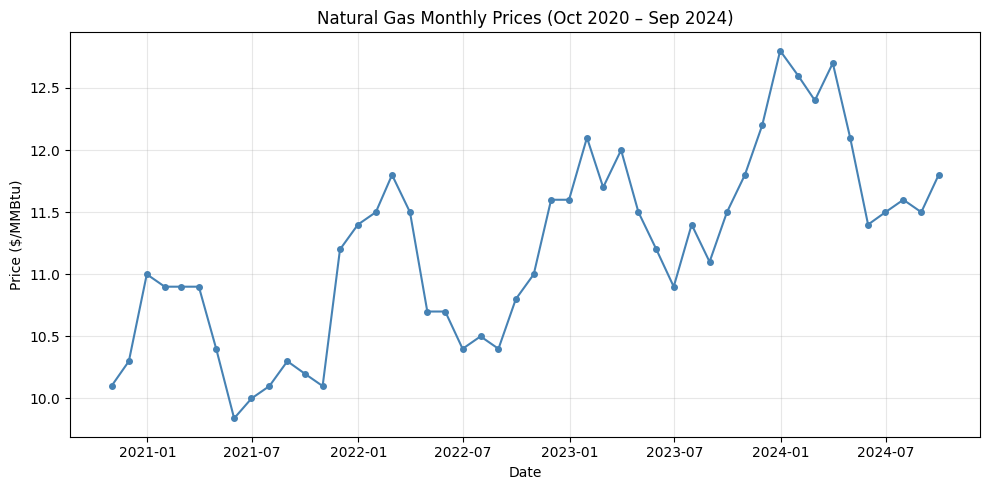

In [2]:
plt.figure(figsize=(10, 5))
plt.plot(df['Dates'], df['Prices'], marker='o', linewidth=1.5, markersize=4, color='steelblue')
plt.title('Natural Gas Monthly Prices (Oct 2020 – Sep 2024)')
plt.xlabel('Date')
plt.ylabel('Price ($/MMBtu)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
def seasonal_model(t, A, B, C1, C2):
    omega = 2 * np.pi / 12
    return A + B * t + C1 * np.sin(omega * t) + C2 * np.cos(omega * t)

t_data = df['t'].values
p_data = df['Prices'].values

params, covariance = curve_fit(seasonal_model, t_data, p_data)
A, B, C1, C2 = params

print(f"Base price (A):     {A:.4f}")
print(f"Monthly trend (B):  {B:.4f}")
print(f"Sin coefficient:    {C1:.4f}")
print(f"Cos coefficient:    {C2:.4f}")

Base price (A):     10.1349
Monthly trend (B):  0.0456
Sin coefficient:    0.6901
Cos coefficient:    -0.0379


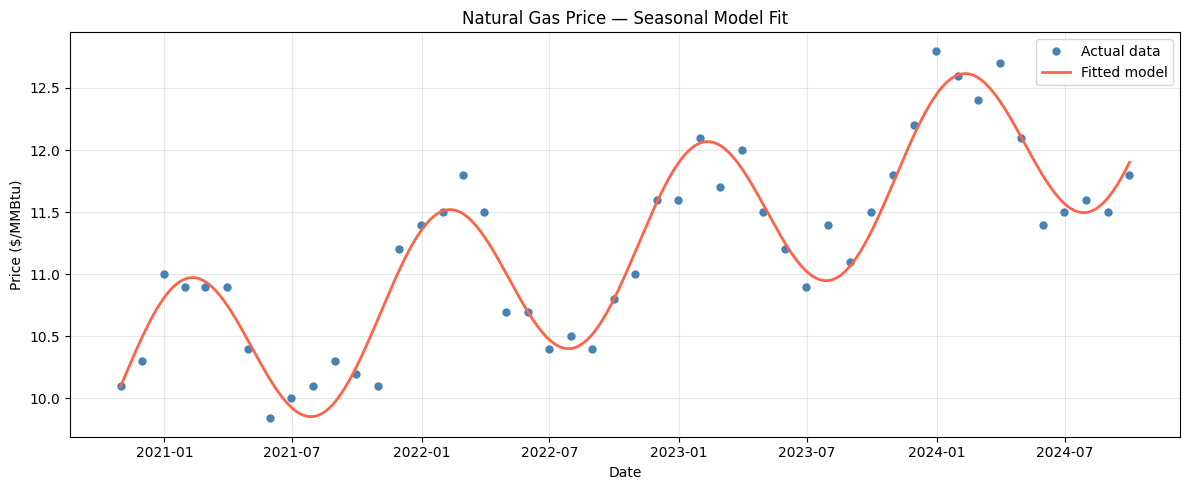

In [4]:
t_fit = np.linspace(0, len(df) - 1, 500)
p_fit = seasonal_model(t_fit, A, B, C1, C2)

plt.figure(figsize=(12, 5))
plt.plot(df['Dates'], df['Prices'], 'o', color='steelblue', label='Actual data', markersize=5)
plt.plot(df['Dates'][0] + pd.to_timedelta(t_fit * 30.44, unit='D'),
         p_fit, color='tomato', linewidth=2, label='Fitted model')
plt.title('Natural Gas Price — Seasonal Model Fit')
plt.xlabel('Date')
plt.ylabel('Price ($/MMBtu)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
reference_date = df['Dates'].iloc[0]  # Oct 31, 2020

def estimate_price(date_str):
    date = pd.to_datetime(date_str)
    # Convert date to fractional months from reference
    t = (date - reference_date).days / 30.44
    price = seasonal_model(t, A, B, C1, C2)
    return round(price, 4)

print(estimate_price('2024-01-15'))   # should be ~12.x (winter)
print(estimate_price('2024-07-15'))   # should be lower (summer)
print(estimate_price('2025-06-30'))   # extrapolation — one year out

12.5432
11.5122
12.1196


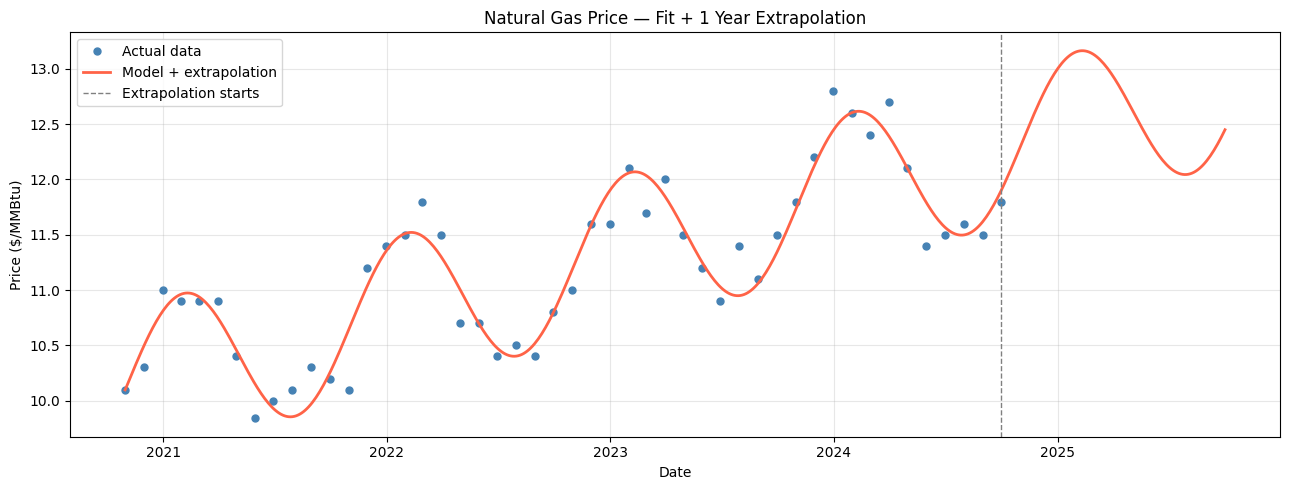

In [6]:
# Extend 12 months beyond last data point
t_extrap = np.linspace(0, len(df) + 11, 600)
p_extrap = seasonal_model(t_extrap, A, B, C1, C2)

# Convert t back to dates for plotting
dates_extrap = reference_date + pd.to_timedelta(t_extrap * 30.44, unit='D')

plt.figure(figsize=(13, 5))
plt.plot(df['Dates'], df['Prices'], 'o', color='steelblue', label='Actual data', markersize=5)
plt.plot(dates_extrap, p_extrap, color='tomato', linewidth=2, label='Model + extrapolation')
plt.axvline(x=df['Dates'].iloc[-1], color='gray', linestyle='--', linewidth=1, label='Extrapolation starts')
plt.title('Natural Gas Price — Fit + 1 Year Extrapolation')
plt.xlabel('Date')
plt.ylabel('Price ($/MMBtu)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
def price_contract(injection_dates, withdrawal_dates,
                   injection_rate, withdrawal_rate,
                   max_storage, storage_cost_per_day,
                   injection_cost_per_mmbtu, withdrawal_cost_per_mmbtu):

    total_value = 0
    current_volume = 0

    # --- INJECTIONS ---
    for date_str in injection_dates:
        buy_price = estimate_price(date_str)
        # How much can we actually inject? Limited by rate AND remaining capacity
        volume = min(injection_rate, max_storage - current_volume)
        if volume <= 0:
            print(f"Warning: Storage full on {date_str}, skipping injection.")
            continue
        current_volume += volume
        total_value -= buy_price * volume               # cost of buying gas
        total_value -= injection_cost_per_mmbtu * volume  # cost of injecting

    # --- STORAGE COST ---
    # Days between first injection and last withdrawal
    first_in  = pd.to_datetime(injection_dates[0])
    last_out  = pd.to_datetime(withdrawal_dates[-1])
    days_stored = (last_out - first_in).days
    total_value -= storage_cost_per_day * days_stored * current_volume

    # --- WITHDRAWALS ---
    for date_str in withdrawal_dates:
        sell_price = estimate_price(date_str)
        # How much can we withdraw? Limited by rate AND what's left
        volume = min(withdrawal_rate, current_volume)
        if volume <= 0:
            print(f"Warning: Storage empty on {date_str}, skipping withdrawal.")
            continue
        current_volume -= volume
        total_value += sell_price * volume                  # revenue from selling
        total_value -= withdrawal_cost_per_mmbtu * volume  # cost of withdrawing

    return round(total_value, 2)

In [10]:
# Test: Buy in summer 2023, sell in winter 2023
result = price_contract(
    injection_dates    = ['2023-06-30', '2023-07-31'],
    withdrawal_dates   = ['2023-12-31', '2024-01-31'],
    injection_rate     = 1_000_000,   # 1M MMBtu/day
    withdrawal_rate    = 1_000_000,
    max_storage        = 3_000_000,   # 3M MMBtu max
    storage_cost_per_day     = 0.10, # $0.10/MMBtu/day
    injection_cost_per_mmbtu = 0.01,
    withdrawal_cost_per_mmbtu= 0.01
)

print(f"Contract Value: ${result:,.2f}")

Contract Value: $-39,970,900.00


In [11]:
#changing the storage,injection and withdrawal cost. because it is  reducing and flagging out
#too much total contract value and increasing the cost
result = price_contract(
    injection_dates   = ['2023-06-30', '2023-07-31'],
    withdrawal_dates  = ['2023-12-31', '2024-01-31'],
    injection_rate    = 1_000_000,
    withdrawal_rate   = 1_000_000,
    max_storage       = 3_000_000,
    storage_cost_per_day      = 0.001,  # realistic: ~$0.03/MMBtu/month
    injection_cost_per_mmbtu  = 0.005,
    withdrawal_cost_per_mmbtu = 0.005
)

print(f"Contract Value: ${result:,.2f}")

Contract Value: $2,619,100.00
